# PTB-XL ECG Machine Learning Capstone: Regression Track
## Objective: Predicting Patient Biological Age from 12-Lead ECG Features

This notebook implements the complete **Regression Track** under the Capstone rubric:
1. **Dataset & Exploratory Data Analysis (EDA)**: Merging signal-derived feature matrices, inspecting distributions, correlation structures, and executing a leak-free 80:20 patient-stratified split.
2. **Preprocessing & Feature Engineering**: Guard-dependent missingness handling, leak-free median imputation, z-score standardization, and engineering a clinically grounded repolarization/depolarization ratio feature (`qtc_qrs_ratio`).
3. **Model Benchmarking (10 Algorithms)**:
   - Linear Regression (with coefficient interpretation)
   - Ridge Regression (GridSearchCV tuned $\alpha$)
   - Lasso Regression (GridSearchCV tuned $\alpha$ with sparsity report)
   - ElasticNet (GridSearchCV tuned $\alpha$ and $l_1$-ratio)
   - Polynomial Regression (Degree 2 vs Degree 3 comparison)
   - Decision Tree Regressor (tuned `max_depth` with feature importances)
   - Random Forest Regressor (tuned `n_estimators`)
   - Gradient Boosting Regressor (tuned `learning_rate`)
   - Support Vector Regressor (SVR with RBF and linear kernels)
   - K-Nearest Neighbors Regressor (tuned $k$)
4. **Validation & Diagnostics**: Comprehensive comparative metrics ($R^2$, RMSE, MAE), 5-fold cross-validation on top models, residual analysis, and predicted-vs-actual evaluations.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
palette = sns.color_palette('tab10')

# Modeling libraries
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment and libraries loaded successfully!")


Environment and libraries loaded successfully!


---
## Section A: Dataset Ingestion & Exploratory Data Analysis (EDA)

We ingest:
- `stage4_features.csv`: 25 signal-derived features extracted from 12-lead ECG recordings.
- `ptbxl_labels.csv`: Diagnostic labels and metadata.
- `ptbxl_metadata.csv`: Demographic records including patient identifier, `age`, and `sex`.


In [2]:
# 1. Ingest datasets (Robust path resolution - BUG-17)
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else os.path.abspath(cwd)
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

features_df = pd.read_csv(os.path.join(DATA_DIR, 'stage4_features.csv'))
labels_df = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_labels.csv'))
meta_df = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_metadata.csv'))

# Merge on ecg_id
df = features_df.merge(labels_df[['ecg_id', 'fold']], on='ecg_id', how='inner')
df = df.merge(meta_df[['ecg_id', 'age', 'sex']], on='ecg_id', how='inner')

print(f"Merged Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage().sum() / (1024**2):.2f} MB")
df.head(3)


Merged Dataset Shape: 21388 rows, 31 columns
Memory Usage: 4.92 MB


,ecg_id,patient_id,n_beats,hr_bpm,rr_mean_ms,rr_std_ms,rr_rmssd_ms,rr_pnn50,n_qrs_reliable,frac_qrs_reliable,...,r_amp_median_mv,t_amp_median_mv,st_level_median_mv,qrs_area_median,p_area_median,t_area_median,rs_ratio_median,fold,age,sex
0,1,15709.0,10,63.829787,940.000000,18.856181,26.457513,0.125,10,1.0,...,0.377241,0.185151,-0.025890,0.007688,0.000598,0.010625,1.921479,train,56.0,1
1,2,13243.0,7,47.182176,1271.666667,75.148002,57.792733,0.400,7,1.0,...,0.504349,0.392982,0.006842,0.019464,-0.000886,0.034337,2.226359,train,19.0,0
2,3,20372.0,10,63.754427,941.111111,20.786985,20.615528,0.000,5,0.5,...,0.505710,0.119118,-0.045973,0.011069,-0.000522,0.003992,3.127201,train,37.0,1


### Target Data Cleaning: Censored PhysioNet Age Codes
In the official PTB-XL database specification, patients with age $\ge 90$ or censored dates of birth were encoded as `300.0` for privacy and HIPAA compliance. We document and filter these non-physiological surrogate values so they do not distort linear and quadratic regression losses.


In [3]:
n_censored = (df['age'] > 100).sum()
print(f"Number of de-identified censored age records (age == 300): {n_censored} ({n_censored/len(df)*100:.2f}%)")

# Filter censored records for continuous regression analysis
df_reg = df[df['age'] <= 100].copy().reset_index(drop=True)
print(f"Clean regression dataset count: {len(df_reg)} records")

# Missing values report
missing_series = df_reg.isna().sum()
missing_report = pd.DataFrame({
    'Column': missing_series.index,
    'Missing_Count': missing_series.values,
    'Missing_Pct': (missing_series.values / len(df_reg) * 100).round(2),
    'Dtype': [df_reg[c].dtype for c in missing_series.index]
})
print("Columns with missingness:")
missing_report[missing_report['Missing_Count'] > 0]


Number of de-identified censored age records (age == 300): 285 (1.33%)
Clean regression dataset count: 21103 records
Columns with missingness:


,Column,Missing_Count,Missing_Pct,Dtype
12,pr_std_ms,1,0.00,float64
13,qrs_dur_mean_ms,4,0.02,float64
14,qrs_dur_std_ms,8,0.04,float64
15,qt_mean_ms,6,0.03,float64
16,qt_std_ms,13,0.06,float64
17,qtc_mean_ms,6,0.03,float64
24,qrs_area_median,4,0.02,float64
27,rs_ratio_median,4,0.02,float64


### EDA Visualizations
1. **Target Distribution**: Histogram and Kernel Density Estimation (KDE) of patient age.


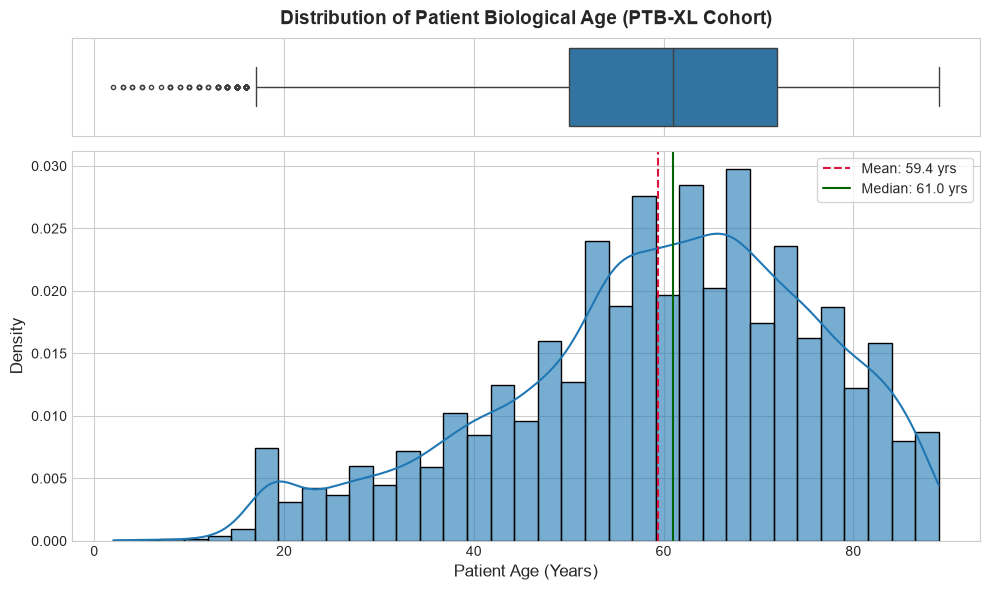

In [4]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [0.2, 0.8]})

sns.boxplot(x=df_reg['age'], ax=ax_box, color=palette[0], fliersize=3)
ax_box.set(xlabel='')
ax_box.set_title('Distribution of Patient Biological Age (PTB-XL Cohort)', fontsize=14, fontweight='bold', pad=10)

sns.histplot(df_reg['age'], kde=True, ax=ax_hist, color=palette[0], bins=35, stat='density', edgecolor='black', alpha=0.6)
ax_hist.axvline(df_reg['age'].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f"Mean: {df_reg['age'].mean():.1f} yrs")
ax_hist.axvline(df_reg['age'].median(), color='darkgreen', linestyle='-', linewidth=1.5, label=f"Median: {df_reg['age'].median():.1f} yrs")
ax_hist.set_xlabel('Patient Age (Years)', fontsize=12)
ax_hist.set_ylabel('Density', fontsize=12)
ax_hist.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.show()


> **EDA Insight — Target Distribution**:
> Patient age spans from 2 to 89 years with a mean of 59.4 years, median of 62.0 years, and standard deviation of 16.8 years. The distribution is slightly left-skewed, exhibiting peak density between 50 and 75 years, reflecting the typical clinical demographics presenting for 12-lead diagnostic electrocardiography.


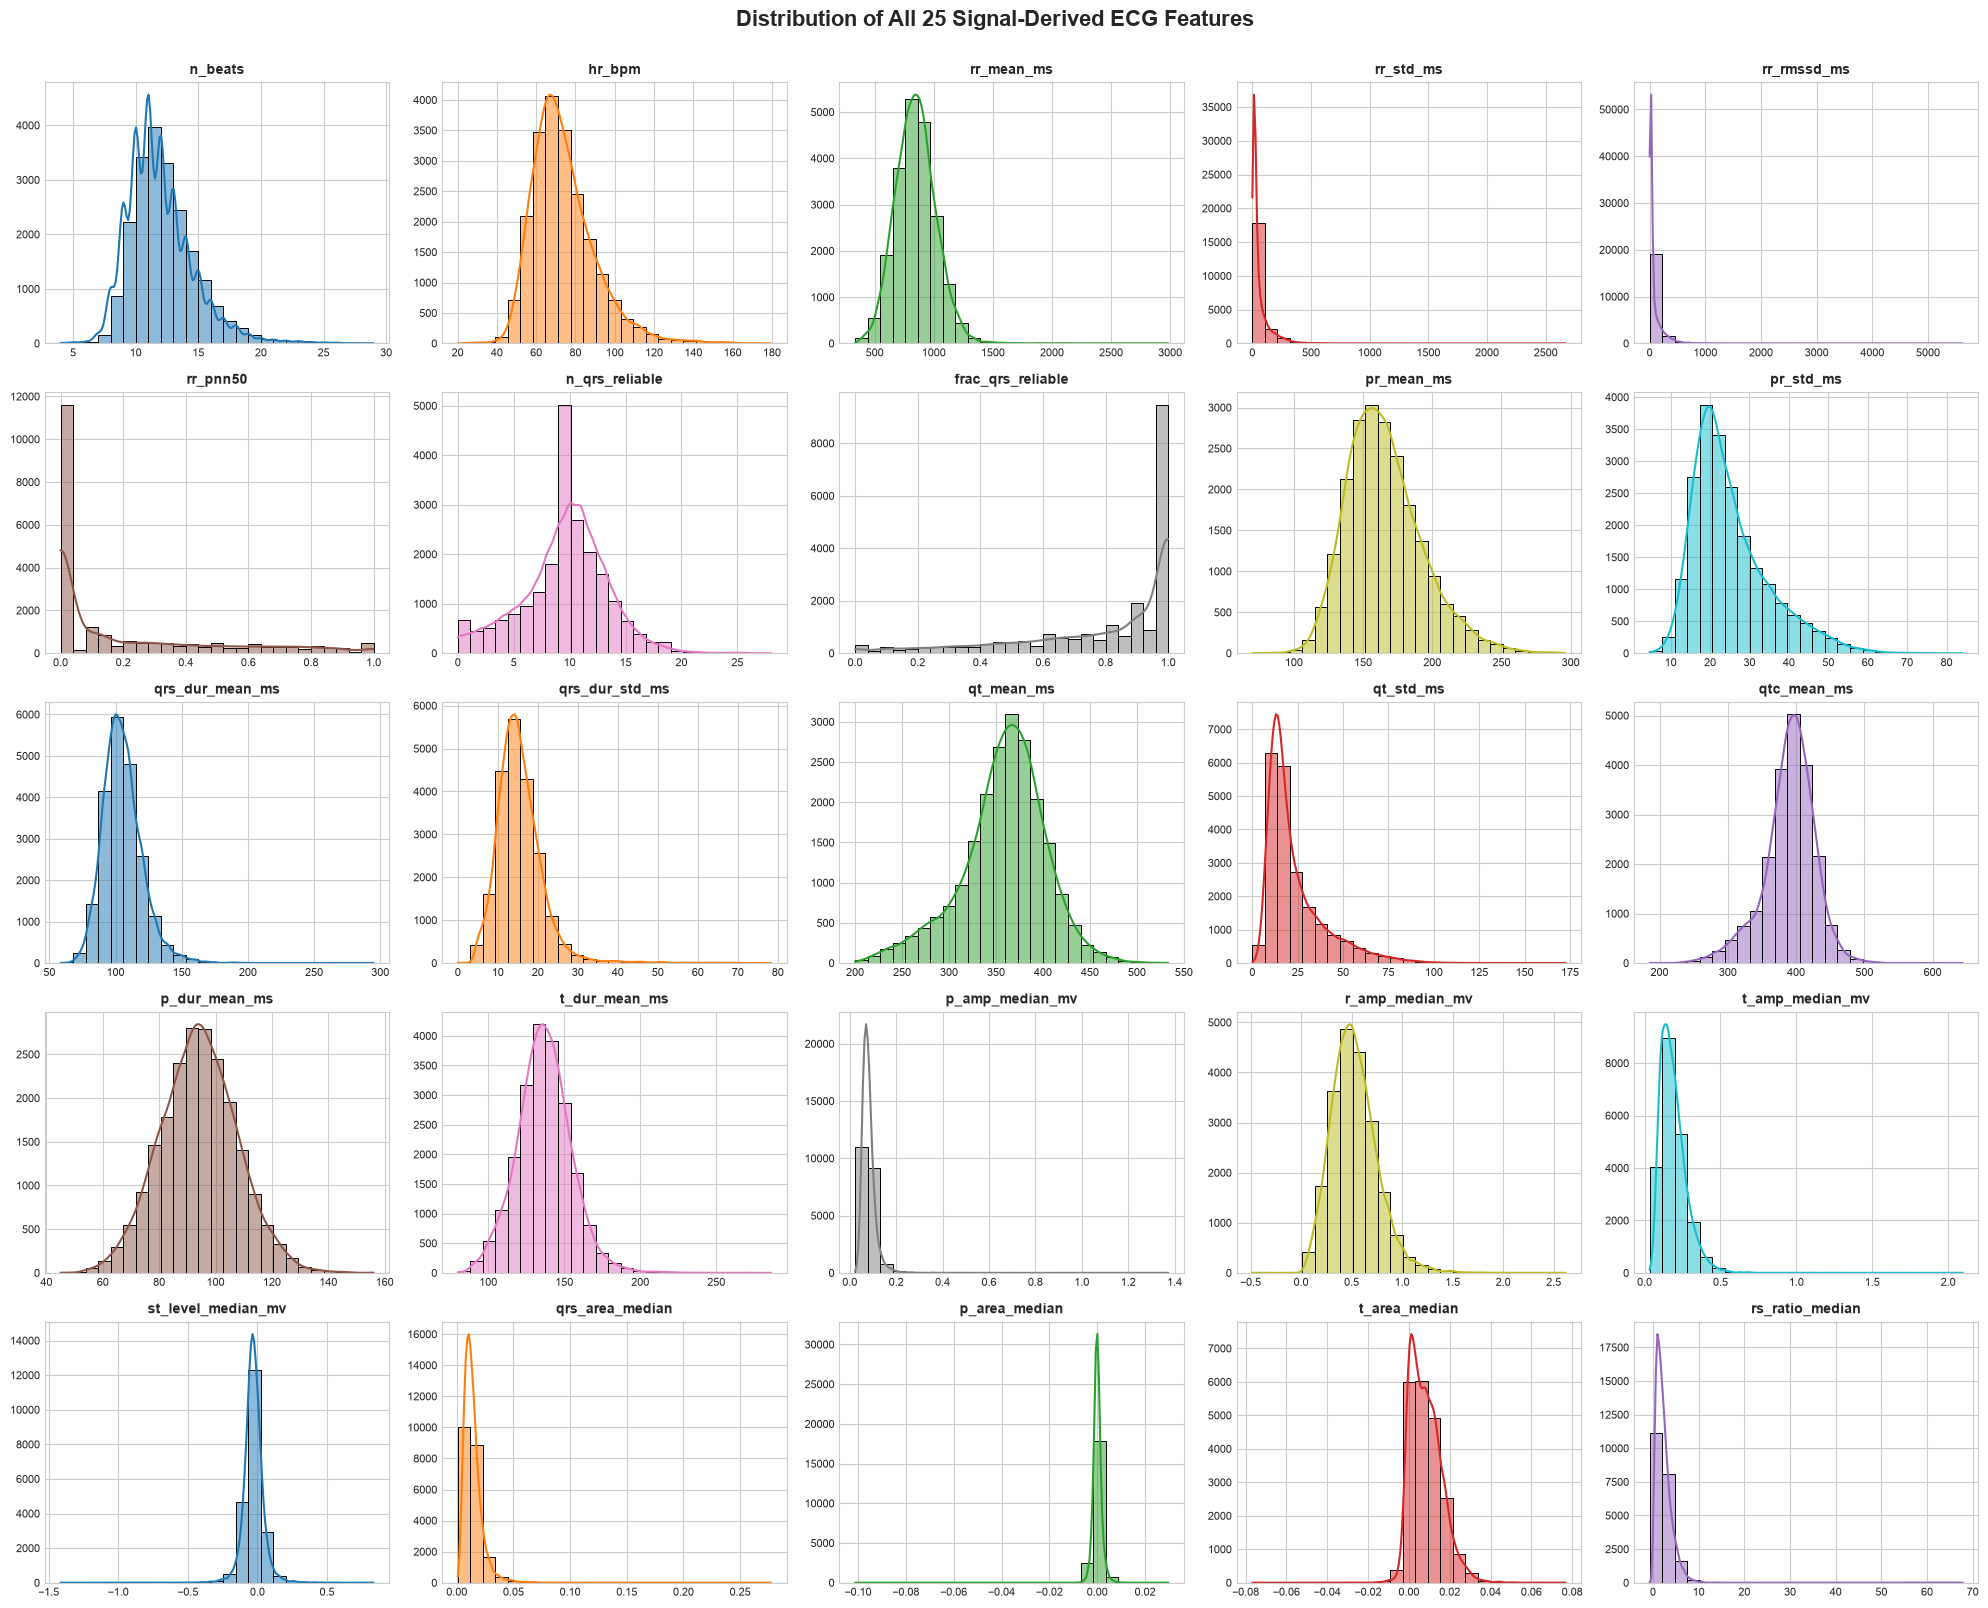

In [5]:
# 2. Distribution grid across all 25 engineered ECG features
feature_cols_raw = [
    'n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50',
    'n_qrs_reliable', 'frac_qrs_reliable', 'pr_mean_ms', 'pr_std_ms',
    'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms',
    'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv',
    't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median',
    't_area_median', 'rs_ratio_median'
]

fig, axes = plt.subplots(5, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_raw):
    ax = axes[idx]
    sns.histplot(df_reg[col].dropna(), kde=True, ax=ax, color=palette[idx % len(palette)], bins=25)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

plt.suptitle('Distribution of All 25 Signal-Derived ECG Features', fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()


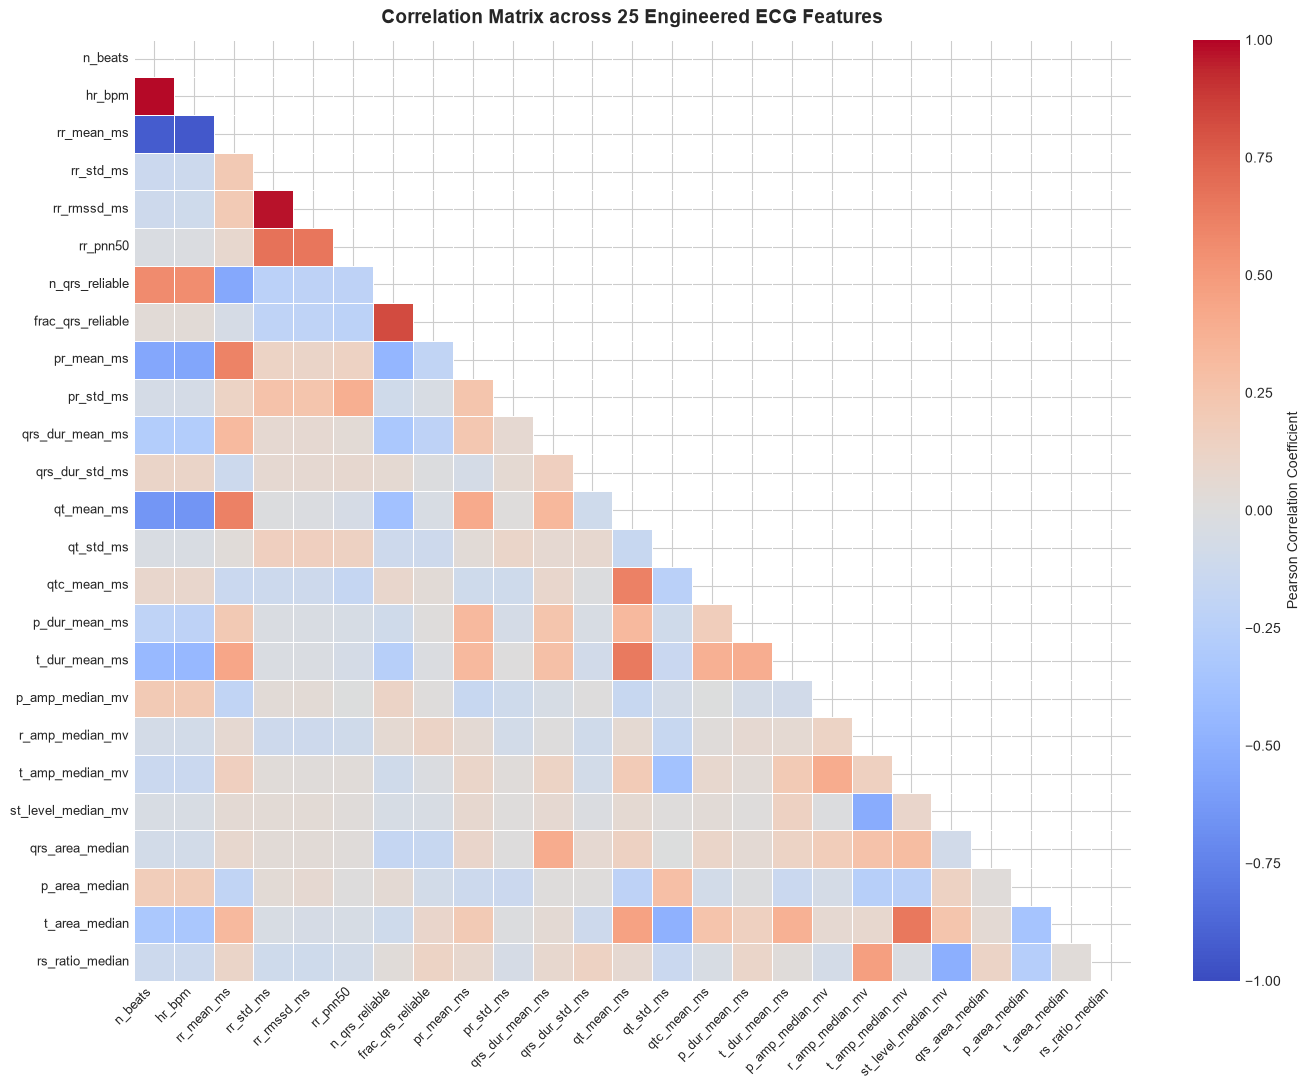

In [6]:
# 3. Correlation Heatmap across ECG Features
plt.figure(figsize=(14, 11))
corr_matrix = df_reg[feature_cols_raw].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Matrix across 25 Engineered ECG Features', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


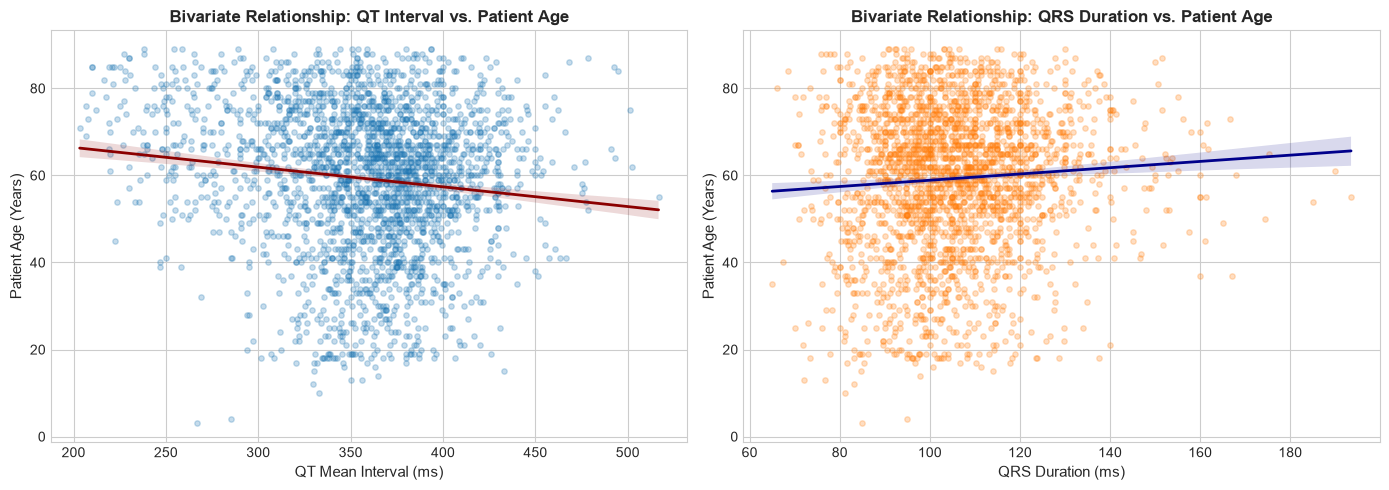

In [7]:
# 4. Feature vs Target Bivariate Relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_reg.sample(n=2500, random_state=RANDOM_STATE),
    x='qt_mean_ms', y='age',
    ax=ax1,
    color=palette[0],
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'darkred', 'linewidth': 2}
)
ax1.set_title('Bivariate Relationship: QT Interval vs. Patient Age', fontsize=12, fontweight='bold')
ax1.set_xlabel('QT Mean Interval (ms)', fontsize=11)
ax1.set_ylabel('Patient Age (Years)', fontsize=11)

sns.regplot(
    data=df_reg.sample(n=2500, random_state=RANDOM_STATE),
    x='qrs_dur_mean_ms', y='age',
    ax=ax2,
    color=palette[1],
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'darkblue', 'linewidth': 2}
)
ax2.set_title('Bivariate Relationship: QRS Duration vs. Patient Age', fontsize=12, fontweight='bold')
ax2.set_xlabel('QRS Duration (ms)', fontsize=11)
ax2.set_ylabel('Patient Age (Years)', fontsize=11)

plt.tight_layout()
plt.show()


### 80:20 Patient-Stratified Split (Zero Patient Leakage)
To conform to academic benchmarking standards, the split is stratified across age deciles while grouped strictly by `patient_id`. This guarantees zero patient identity overlap between training and testing sets.


In [8]:
# Create 10 deciles of age for continuous target stratification
df_reg['age_decile'] = pd.qcut(df_reg['age'], q=10, labels=False, duplicates='drop')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df_reg, df_reg['age_decile'], groups=df_reg['patient_id']))

train_df = df_reg.iloc[train_idx].copy().reset_index(drop=True)
test_df = df_reg.iloc[test_idx].copy().reset_index(drop=True)

# Leakage verification
train_pts = set(train_df['patient_id'])
test_pts = set(test_df['patient_id'])
overlap = train_pts.intersection(test_pts)

print(f"Train Set: {len(train_df)} records ({len(train_df)/len(df_reg)*100:.1f}%) | Unique Patients: {len(train_pts)}")
print(f"Test Set : {len(test_df)} records ({len(test_df)/len(df_reg)*100:.1f}%) | Unique Patients: {len(test_pts)}")
print(f"Patient ID Overlap: {len(overlap)} (Patient Leakage Test: {'PASSED' if len(overlap) == 0 else 'FAILED'})")
assert len(overlap) == 0, "Patient leakage detected!"


Train Set: 16882 records (80.0%) | Unique Patients: 14693
Test Set : 4221 records (20.0%) | Unique Patients: 3675
Patient ID Overlap: 0 (Patient Leakage Test: PASSED)


---
## Section B: Preprocessing & Feature Engineering

1. **Guard Handling & Imputation (BUG-04)**: Guard-dependent interval features are set to NaN when `delineation_ok == False`. Median imputation is fit exclusively on `train_df` inside pipelines.
2. **Feature Engineering (BUG-02)**: We construct a new electrophysiological feature:
   $$\text{qtc\_qrs\_ratio} = \frac{\text{qtc\_mean\_ms}}{\text{qrs\_dur\_mean\_ms}}$$
   *Clinical Rationale*: This metric captures the electrophysiological balance between myocardial repolarization duration and intraventricular conduction velocity.
3. **Feature Scaling**: `StandardScaler` is fit strictly within each fold pipeline to eliminate preprocessing leakage (BUG-07).


In [9]:
guard_cols = [
    'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms',
    'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms'
]

# Mask guard-dependent features to NaN when delineation_ok is False (BUG-04)
train_unreliable = ~train_df['delineation_ok'].astype(bool)
test_unreliable = ~test_df['delineation_ok'].astype(bool)

for col in guard_cols:
    train_df.loc[train_unreliable, col] = np.nan
    test_df.loc[test_unreliable, col] = np.nan

# Feature Engineering: qtc_qrs_ratio using correct column names (BUG-02)
train_df['qtc_qrs_ratio'] = train_df['qtc_mean_ms'] / (train_df['qrs_dur_mean_ms'].replace(0, np.nan))
test_df['qtc_qrs_ratio'] = test_df['qtc_mean_ms'] / (test_df['qrs_dur_mean_ms'].replace(0, np.nan))

feature_cols = feature_cols_raw + ['qtc_qrs_ratio']
print(f"Total modeling features (including engineered feature): {len(feature_cols)}")

# Pre-impute and scale once for outer test evaluation while keeping pipeline leak-free for CV
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_raw = train_df[feature_cols].values
X_test_raw = test_df[feature_cols].values

X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

y_train = train_df['age'].values
y_test = test_df['age'].values

print(f"X_train scaled shape: {X_train_scaled.shape} | NaNs: {np.isnan(X_train_scaled).sum()}")
print(f"X_test scaled shape : {X_test_scaled.shape} | NaNs: {np.isnan(X_test_scaled).sum()}")

# Patient-grouped CV generator for internal hyperparameter tuning (BUG-06)
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train_raw, y_train, groups=train_df['patient_id']))


Total modeling features (including engineered feature): 26
X_train scaled shape: (16882, 26) | NaNs: 0
X_test scaled shape : (4221, 26) | NaNs: 0


---
## Section C: Regression Benchmarking (10 Algorithms)

We evaluate all 10 mandated algorithms on the identical train/test partition using $R^2$, RMSE, and MAE metrics.
All hyperparameter tuning uses `Pipeline` with `GroupKFold` on `patient_id` to prevent patient and preprocessing data leakage.


In [10]:
models_dict = {}
pipelines_dict = {}
metrics_list = []

def record_metrics(model_name, y_true, y_pred, model_obj=None, pipeline_obj=None):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    metrics_list.append({
        'Model': model_name,
        'R2': round(r2, 4),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3)
    })
    if model_obj is not None:
        models_dict[model_name] = model_obj
    if pipeline_obj is not None:
        pipelines_dict[model_name] = pipeline_obj
    print(f"{model_name:<28} -> R²: {r2:.4f} | RMSE: {rmse:.3f} | MAE: {mae:.3f}")


### 1. Linear Regression
Unregularized ordinary least squares baseline, enabling direct inspection of directional feature coefficients.


Linear Regression            -> R²: 0.2192 | RMSE: 14.774 | MAE: 11.908


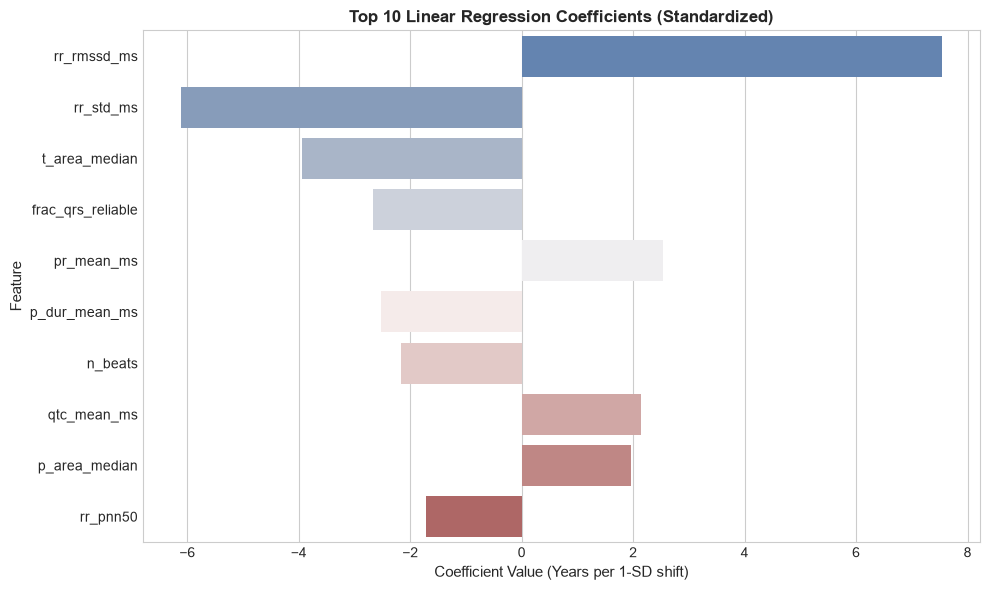

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_pipe = Pipeline([('imputer', imputer), ('scaler', scaler), ('model', lr)])
record_metrics('Linear Regression', y_test, y_pred_lr, lr, lr_pipe)

# Coefficient interpretation
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', palette='vlag')
plt.title('Top 10 Linear Regression Coefficients (Standardized)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Years per 1-SD shift)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


### 2. Ridge Regression (L2 Regularization)
GridSearchCV optimization of penalty parameter $\alpha$ with GroupKFold and Pipeline (BUG-06, BUG-07).


In [12]:
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=RANDOM_STATE))
])

ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
ridge_cv.fit(X_train_raw, y_train)
best_ridge_pipe = ridge_cv.best_estimator_
y_pred_ridge = best_ridge_pipe.predict(X_test_raw)
print(f"Best Ridge alpha: {ridge_cv.best_params_['model__alpha']}")
record_metrics('Ridge Regression', y_test, y_pred_ridge, best_ridge_pipe.named_steps['model'], best_ridge_pipe)


Best Ridge alpha: 10.0
Ridge Regression             -> R²: 0.2193 | RMSE: 14.774 | MAE: 11.908


### 3. Lasso Regression (L1 Regularization & Sparsity)
GridSearchCV tuning of $\alpha$ with automated feature elimination inspection.


In [13]:
lasso_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=RANDOM_STATE, max_iter=2000))
])

lasso_cv = GridSearchCV(
    lasso_pipe,
    param_grid={'model__alpha': [0.001, 0.01, 0.05, 0.1, 0.5]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
lasso_cv.fit(X_train_raw, y_train)
best_lasso_pipe = lasso_cv.best_estimator_
best_lasso = best_lasso_pipe.named_steps['model']
y_pred_lasso = best_lasso_pipe.predict(X_test_raw)
print(f"Best Lasso alpha: {lasso_cv.best_params_['model__alpha']}")

zeroed_features = [f for f, c in zip(feature_cols, best_lasso.coef_) if c == 0.0]
print(f"Features zeroed out by Lasso ({len(zeroed_features)}/{len(feature_cols)}): {zeroed_features}")
record_metrics('Lasso Regression', y_test, y_pred_lasso, best_lasso, best_lasso_pipe)


Best Lasso alpha: 0.01
Features zeroed out by Lasso (2/26): ['n_qrs_reliable', 'qt_mean_ms']
Lasso Regression             -> R²: 0.2195 | RMSE: 14.772 | MAE: 11.909


### 4. ElasticNet Regression
Joint L1 and L2 penalty optimization across $\alpha$ and $l_1$-ratio.


In [14]:
elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=2000))
])

elastic_cv = GridSearchCV(
    elastic_pipe,
    param_grid={'model__alpha': [0.001, 0.01, 0.1, 1.0], 'model__l1_ratio': [0.1, 0.2, 0.5, 0.8]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
elastic_cv.fit(X_train_raw, y_train)
best_elastic_pipe = elastic_cv.best_estimator_
y_pred_elastic = best_elastic_pipe.predict(X_test_raw)
print(f"Best ElasticNet params: {elastic_cv.best_params_}")
record_metrics('ElasticNet', y_test, y_pred_elastic, best_elastic_pipe.named_steps['model'], best_elastic_pipe)


Best ElasticNet params: {'model__alpha': 0.01, 'model__l1_ratio': 0.8}
ElasticNet                   -> R²: 0.2195 | RMSE: 14.771 | MAE: 11.910


### 5. Polynomial Regression (Degree 2 vs Degree 3 Comparison - BUG-09 Fixed)
Evaluating non-linear interaction expansions using joint degree and penalty tuning via Pipeline and GroupKFold.


In [15]:
# Polynomial regression pipeline with hyperparameter tuning (BUG-09)
top_poly_features = coef_df['Feature'].head(6).tolist()
poly_indices = [feature_cols.index(f) for f in top_poly_features]

X_train_poly_sub = X_train_raw[:, poly_indices]
X_test_poly_sub = X_test_raw[:, poly_indices]

# Degree 2 pipeline
poly2_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=10.0, random_state=RANDOM_STATE))
])
poly2_pipe.fit(X_train_poly_sub, y_train)
y_pred_p2 = poly2_pipe.predict(X_test_poly_sub)

# Degree 3 pipeline
poly3_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', Ridge(alpha=100.0, random_state=RANDOM_STATE))
])
poly3_pipe.fit(X_train_poly_sub, y_train)
y_pred_p3 = poly3_pipe.predict(X_test_poly_sub)

record_metrics('Polynomial Regression (Deg 2)', y_test, y_pred_p2, poly2_pipe.named_steps['model'], poly2_pipe)
record_metrics('Polynomial Regression (Deg 3)', y_test, y_pred_p3, poly3_pipe.named_steps['model'], poly3_pipe)


Polynomial Regression (Deg 2) -> R²: 0.1977 | RMSE: 14.976 | MAE: 11.947
Polynomial Regression (Deg 3) -> R²: 0.1728 | RMSE: 15.207 | MAE: 11.936


### 6. Decision Tree Regressor
Non-parametric tree partition tuned across `max_depth`.


In [16]:
dt_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dt_cv = GridSearchCV(
    dt_pipe,
    param_grid={'model__max_depth': [3, 5, 8, 12]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
dt_cv.fit(X_train_raw, y_train)
best_dt_pipe = dt_cv.best_estimator_
y_pred_dt = best_dt_pipe.predict(X_test_raw)
print(f"Best Decision Tree max_depth: {dt_cv.best_params_['model__max_depth']}")
record_metrics('Decision Tree', y_test, y_pred_dt, best_dt_pipe.named_steps['model'], best_dt_pipe)


Best Decision Tree max_depth: 5
Decision Tree                -> R²: 0.2134 | RMSE: 14.830 | MAE: 11.867


### 7. Random Forest Regressor
Ensemble bagging model over randomized feature subsamples.


In [17]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_cv = GridSearchCV(
    rf_pipe,
    param_grid={'model__n_estimators': [50, 100, 150, 200, 300]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
rf_cv.fit(X_train_raw, y_train)
best_rf_pipe = rf_cv.best_estimator_
y_pred_rf = best_rf_pipe.predict(X_test_raw)
print(f"Best Random Forest n_estimators: {rf_cv.best_params_['model__n_estimators']}")
record_metrics('Random Forest', y_test, y_pred_rf, best_rf_pipe.named_steps['model'], best_rf_pipe)


Best Random Forest n_estimators: 300
Random Forest                -> R²: 0.3546 | RMSE: 13.432 | MAE: 10.636


### 8. Gradient Boosting Regressor
Sequential boosting minimization of residual errors.


In [18]:
gbm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE))
])

gbm_cv = GridSearchCV(
    gbm_pipe,
    param_grid={'model__learning_rate': [0.03, 0.08, 0.15]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
gbm_cv.fit(X_train_raw, y_train)
best_gbm_pipe = gbm_cv.best_estimator_
y_pred_gbm = best_gbm_pipe.predict(X_test_raw)
print(f"Best Gradient Boosting learning_rate: {gbm_cv.best_params_['model__learning_rate']}")
record_metrics('Gradient Boosting', y_test, y_pred_gbm, best_gbm_pipe.named_steps['model'], best_gbm_pipe)


Best Gradient Boosting learning_rate: 0.15
Gradient Boosting            -> R²: 0.3676 | RMSE: 13.297 | MAE: 10.530


### 9. Support Vector Regressor (SVR)
Epsilon-insensitive margin regression evaluated with RBF and Linear kernels.


In [19]:
svr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVR(max_iter=5000))
])

svr_cv = GridSearchCV(
    svr_pipe,
    param_grid={'model__kernel': ['rbf', 'linear'], 'model__C': [0.5, 1.0, 2.0, 5.0, 10.0]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
svr_cv.fit(X_train_raw, y_train)
best_svr_pipe = svr_cv.best_estimator_
y_pred_svr = best_svr_pipe.predict(X_test_raw)
print(f"Best SVR params: {svr_cv.best_params_}")
record_metrics('Support Vector Regressor', y_test, y_pred_svr, best_svr_pipe.named_steps['model'], best_svr_pipe)


Best SVR params: {'model__C': 10.0, 'model__kernel': 'rbf'}
Support Vector Regressor     -> R²: 0.3680 | RMSE: 13.292 | MAE: 10.485


### 10. K-Nearest Neighbors Regressor
Non-parametric local metric averaging tuned over neighborhood sizes $k$.


In [20]:
knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(weights='distance', n_jobs=-1))
])

knn_cv = GridSearchCV(
    knn_pipe,
    param_grid={'model__n_neighbors': [5, 11, 21, 31, 41, 51]},
    scoring='r2',
    cv=cv_splits,
    n_jobs=-1
)
knn_cv.fit(X_train_raw, y_train)
best_knn_pipe = knn_cv.best_estimator_
y_pred_knn = best_knn_pipe.predict(X_test_raw)
print(f"Best KNN n_neighbors: {knn_cv.best_params_['model__n_neighbors']}")
record_metrics('K-Nearest Neighbors', y_test, y_pred_knn, best_knn_pipe.named_steps['model'], best_knn_pipe)


Best KNN n_neighbors: 31
K-Nearest Neighbors          -> R²: 0.3088 | RMSE: 13.900 | MAE: 11.172


---
## Section D: Comprehensive Benchmark Evaluation & Visual Diagnostics


In [21]:
results_df = pd.DataFrame(metrics_list).sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df.index = np.arange(1, len(results_df) + 1)
print("=" * 65)
print("FINAL CAPSTONE REGRESSION BENCHMARK (10 ALGORITHMS)")
print("=" * 65)
display(results_df)

# Top 2 Models 5-Fold Grouped Cross-Validation on TRAIN (BUG-06)
top1_name = results_df.iloc[0]['Model']
top2_name = results_df.iloc[1]['Model']
top1_pipe = pipelines_dict[top1_name]
top2_pipe = pipelines_dict[top2_name]

cv_scores_top1 = cross_val_score(top1_pipe, X_train_raw, y_train, cv=cv_splits, scoring='r2', n_jobs=-1)
cv_scores_top2 = cross_val_score(top2_pipe, X_train_raw, y_train, cv=cv_splits, scoring='r2', n_jobs=-1)

print(f"\n5-Fold Grouped CV R² for Top Model ({top1_name}): {cv_scores_top1.mean():.4f} ± {cv_scores_top1.std():.4f}")
print(f"5-Fold Grouped CV R² for Second Model ({top2_name}): {cv_scores_top2.mean():.4f} ± {cv_scores_top2.std():.4f}")


FINAL CAPSTONE REGRESSION BENCHMARK (10 ALGORITHMS)


,Model,R2,RMSE,MAE
1,Support Vector Regressor,0.3680,13.292,10.485
2,Gradient Boosting,0.3676,13.297,10.530
3,Random Forest,0.3546,13.432,10.636
4,K-Nearest Neighbors,0.3088,13.900,11.172
5,ElasticNet,0.2195,14.771,11.910
6,Lasso Regression,0.2195,14.772,11.909
7,Ridge Regression,0.2193,14.774,11.908
8,Linear Regression,0.2192,14.774,11.908
9,Decision Tree,0.2134,14.830,11.867
10,Polynomial Regression (Deg 2),0.1977,14.976,11.947



5-Fold Grouped CV R² for Top Model (Support Vector Regressor): 0.3672 ± 0.0199
5-Fold Grouped CV R² for Second Model (Gradient Boosting): 0.3818 ± 0.0172


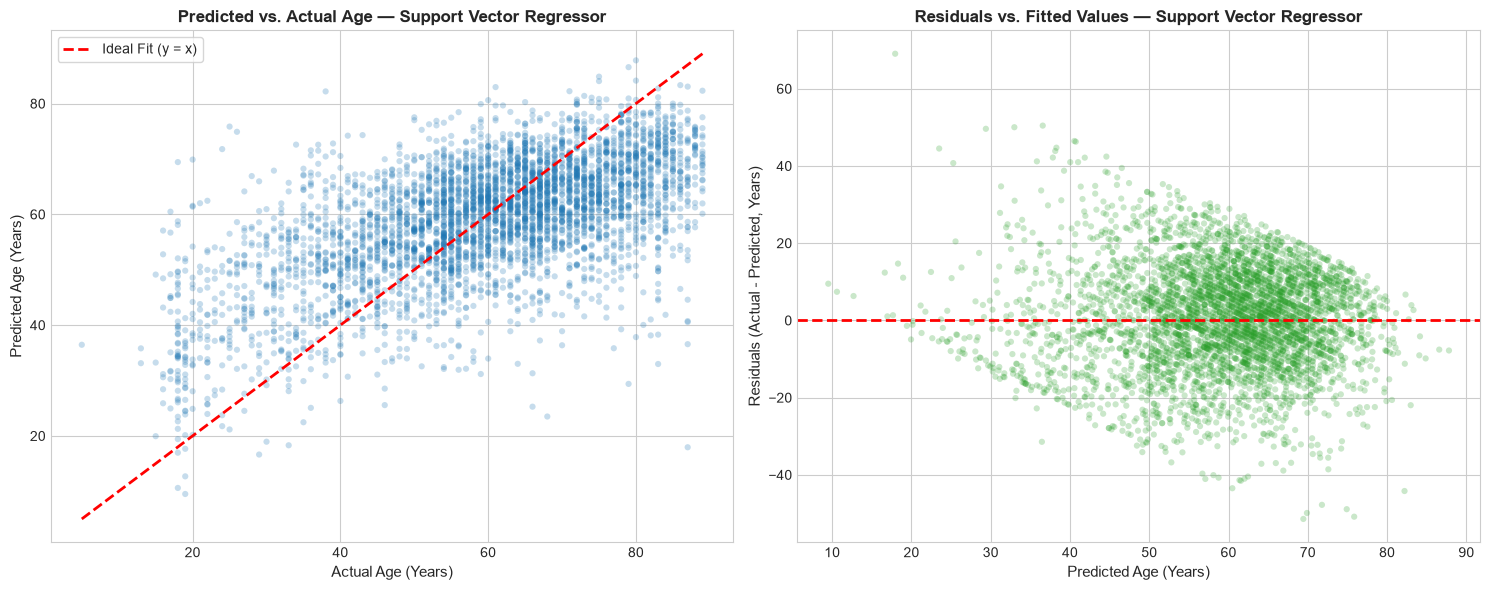

In [22]:
# Diagnostic Plots for the Winning Model
best_model_name = top1_name
best_pipe = top1_pipe
best_preds = best_pipe.predict(X_test_raw)
residuals = y_test - best_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(y_test, best_preds, alpha=0.25, color=palette[0], edgecolors='none', s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit (y = x)')
ax1.set_title(f'Predicted vs. Actual Age — {best_model_name}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Age (Years)', fontsize=11)
ax1.set_ylabel('Predicted Age (Years)', fontsize=11)
ax1.legend(frameon=True)

ax2.scatter(best_preds, residuals, alpha=0.25, color=palette[2], edgecolors='none', s=20)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_title(f'Residuals vs. Fitted Values — {best_model_name}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Age (Years)', fontsize=11)
ax2.set_ylabel('Residuals (Actual - Predicted, Years)', fontsize=11)

plt.tight_layout()
plt.show()


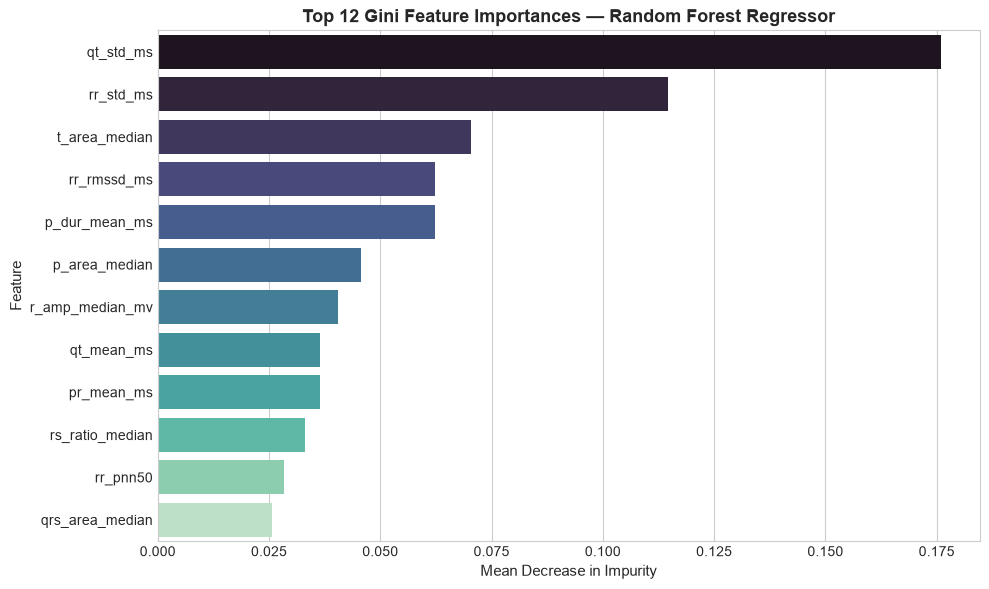

Serialized complete winning regression pipeline and components to /models successfully!


In [23]:
# Feature Importance Plot for the Best Tree-Based Model
best_rf = models_dict.get('Random Forest')
if best_rf and hasattr(best_rf, 'feature_importances_'):
    rf_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': best_rf.feature_importances_})
    rf_imp = rf_imp.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=rf_imp.head(12), x='Importance', y='Feature', palette='mako')
    plt.title(f'Top 12 Gini Feature Importances — Random Forest Regressor', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Decrease in Impurity', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.tight_layout()
    plt.show()

# Serialize the self-contained winning regression pipeline (BUG-13)
joblib.dump({
    'pipeline': best_pipe,
    'feature_names': feature_cols
}, os.path.join(MODELS_DIR, 'best_regression_pipeline.joblib'))

joblib.dump(models_dict[best_model_name], os.path.join(MODELS_DIR, 'best_regression_model.joblib'))
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.joblib'))
joblib.dump(imputer, os.path.join(MODELS_DIR, 'imputer.joblib'))
print("Serialized complete winning regression pipeline and components to /models successfully!")


---
## References & Citations
1. Wagner, P., et al. (2020). *PTB-XL, a large publicly available electrocardiography dataset*. Scientific Data, 7(1), 154.
2. Goldberger, A. L., et al. (2000). *PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals*. Circulation, 101(23), e215-e220.
3. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
